## 3. Cutout images

This notebook shows how to make a small image cutout from a larger coadd image.

The idea is:

- connect to the Butler,
- find the coadd collection,
- load one example coadd image,
- choose a position on the image,
- extract a cutout around that position.

### 3.1 Imports

We import a small set of packages for Butler access, image display, and sky coordinates.


In [1]:
import matplotlib.pyplot as plt
import lsst.afw.display as afwDisplay
import lsst.geom as geom
from lsst.daf.butler import Butler

afwDisplay.setDefaultBackend("matplotlib")

### 3.2 Open the Butler

We use the `lsst-ir-fusion` Butler on UK RSP.


In [2]:
butler = Butler("lsst-ir-fusion")
registry = butler.registry

print("Butler opened successfully")

Butler opened successfully


### 3.3 Find the coadd collection

In [3]:
all_collections = sorted(registry.queryCollections())

coadd_matches = [c for c in all_collections if "videoCoaddDetect" in c]

print("Coadd collections:")
for c in coadd_matches:
    print(" ", c)

coadd_collection = 'u/dc-park2/DRP/videoCoaddDetect/20260116T115441Z'   # Later on RSP coadd_matches[0]
print("\nSelected coadd collection:")
print(coadd_collection)

Coadd collections:
  u/dc-park2/DRP/videoCoaddDetect/20260116T115441Z

Selected coadd collection:
u/dc-park2/DRP/videoCoaddDetect/20260116T115441Z


### 3.4 Create a Butler for the coadd collection

This makes later commands shorter and easier to read.

In [4]:
coadd_butler = Butler("lsst-ir-fusion", collections=coadd_collection)

### 3.5 Select one example tract, patch and band


In [5]:
skymap_name = "hscPdr2"
my_tract = 8524
my_patch = 80
my_band = "K"

dataId = {
    "skymap": skymap_name,
    "tract": my_tract,
    "patch": my_patch,
    "band": my_band,
}

print("Selected data ID:")
print(dataId)

Selected data ID:
{'skymap': 'hscPdr2', 'tract': 8524, 'patch': 80, 'band': 'K'}


### 3.6 Load the coadd image

Now we read the coadd exposure for this example patch.


In [6]:
coadd = coadd_butler.get("deepCoadd_calexp", **dataId)

### 3.7 Display the full image

This lets us see the patch before making a cutout.

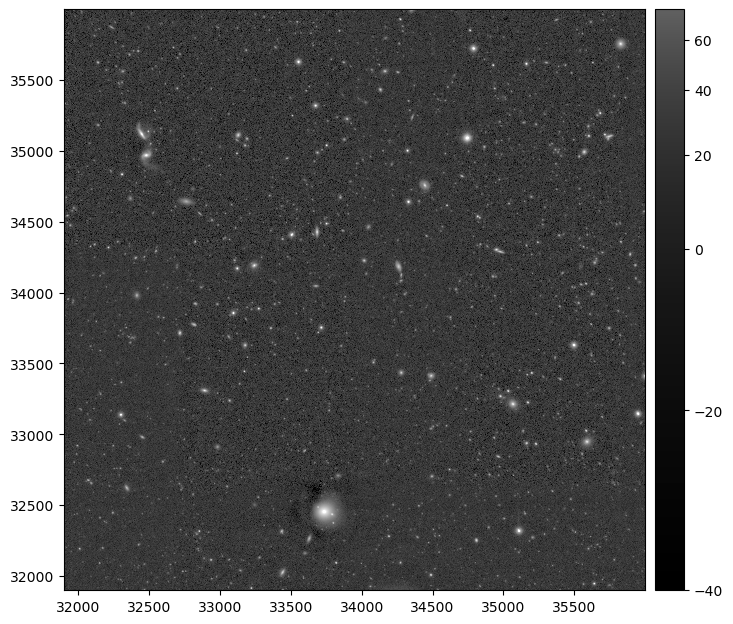

In [7]:
fig, ax = plt.subplots(figsize=(8, 8))
display = afwDisplay.Display(frame=fig)
display.scale("asinh", "zscale")
display.mtv(coadd.image)
plt.show()

### 3.8 Choose a position for the cutout

For a simple example, we use a position near the centre of the image.
We first convert pixel coordinates to sky coordinates, because our cutout function will use RA and Dec.


In [8]:
bbox = coadd.getBBox()
x_centre = (bbox.getMinX() + bbox.getMaxX()) // 2
y_centre = (bbox.getMinY() + bbox.getMaxY()) // 2

radec = coadd.getWcs().pixelToSky(x_centre, y_centre)
ra = radec.getRa().asDegrees()
dec = radec.getDec().asDegrees()

print(f"Pixel position : ({x_centre}, {y_centre})")
print(f"RA, Dec [deg] : ({ra:.6f}, {dec:.6f})")

Pixel position : (33949, 33949)
RA, Dec [deg] : (34.955988, -4.461943)


### 3.9 Define a cutout function

This function takes:

- a Butler,
- sky coordinates,
- a `dataId`,
- and a cutout size in pixels.

It returns the image cutout.

In [9]:
def cutout_coadd(butler, ra, dec, dataId, cutoutSideLength=200):
    radec = geom.SpherePoint(ra, dec, geom.degrees)
    cutout_size = geom.ExtentI(cutoutSideLength, cutoutSideLength)

    calexp_wcs = butler.get("deepCoadd_calexp.wcs", dataId=dataId)
    xy = geom.PointI(calexp_wcs.skyToPixel(radec))
    bbox = geom.BoxI(xy - cutout_size // 2, cutout_size)

    cutout_image = butler.get("deepCoadd_calexp.image", dataId=dataId, parameters={"bbox": bbox})
    return cutout_image

### 3.10 Extract the cutout

Now we create a cutout around the sky position chosen above.

In [10]:
cutout = cutout_coadd(coadd_butler, ra, dec, dataId, cutoutSideLength=200)

### 3.11 Display the cutout

This is the final small image around our chosen position.

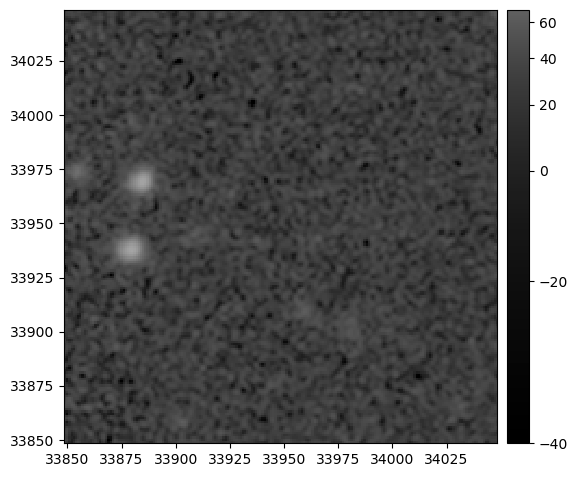

In [11]:
fig, ax = plt.subplots(figsize=(6, 6))
display = afwDisplay.Display(frame=fig)
display.scale("asinh", "zscale")
display.mtv(cutout)
plt.show()

### 3.12 Try your own target

To inspect another object, replace `ra` and `dec` with your own coordinates and run the cutout cell again.

You can also change `cutoutSideLength`:
- smaller value: tighter view,
- larger value: wider view.